In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:

# --- 1. carregar o dataset ---
ARQUIVO_ENTRADA = 'dataset_artigo.csv'

try:
    df = pd.read_csv(ARQUIVO_ENTRADA)
    print(f"Dataset '{ARQUIVO_ENTRADA}' carregado com sucesso, contendo {len(df)} linhas.")
except FileNotFoundError:
    print(f"ERRO: O arquivo '{ARQUIVO_ENTRADA}' não foi encontrado.")
    df = None


Dataset 'dataset_artigo.csv' carregado com sucesso, contendo 421 linhas.

--- Matriz de Correlação Calculada ---
                      epss  ppsi_normalizado
epss              1.000000          0.193447
ppsi_normalizado  0.193447          1.000000


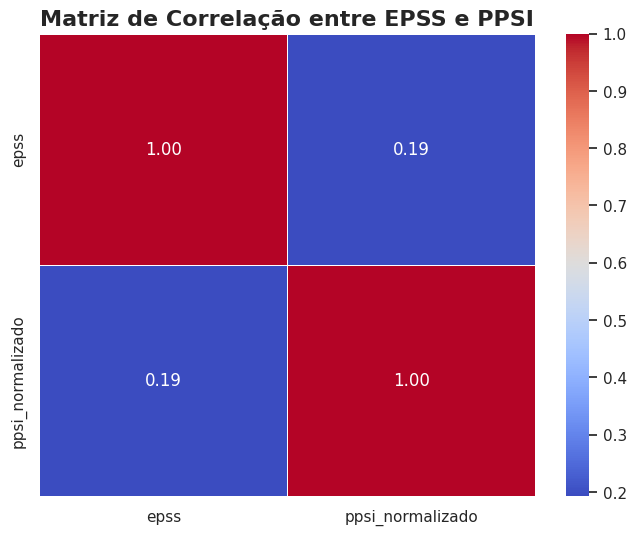

In [33]:
if df is not None:
    # seleciona as colunas para a análise de correlação
    colunas_para_correlacao = ['epss', 'ppsi_normalizado']

    if not all(col in df.columns for col in colunas_para_correlacao):
        print(f"ERRO: O dataset não contém as colunas necessárias: {colunas_para_correlacao}")
    else:
        df_metricas = df[colunas_para_correlacao]

        # --- 2. calculando a matriz de correlação ---
        matriz_correlacao = df_metricas.corr()

        print("\n--- Matriz de Correlação Calculada ---")
        print(matriz_correlacao)

        # --- 3. gerando o gráfico (heatmap) ---
        plt.figure(figsize=(8, 6))

        sns.heatmap(
            matriz_correlacao,
            annot=True,        # exibe os valores numéricos no gráfico
            cmap='coolwarm',   # paleta de cores (azul para negativo, vermelho para positivo)
            fmt=".2f",         # formata os números com duas casas decimais
            linewidths=.5
        )

        plt.title('Matriz de Correlação entre EPSS e PPSI', fontsize=16, weight='bold')
        plt.show()

Dataset 'dataset_artigo.csv' carregado com sucesso, contendo 421 linhas.


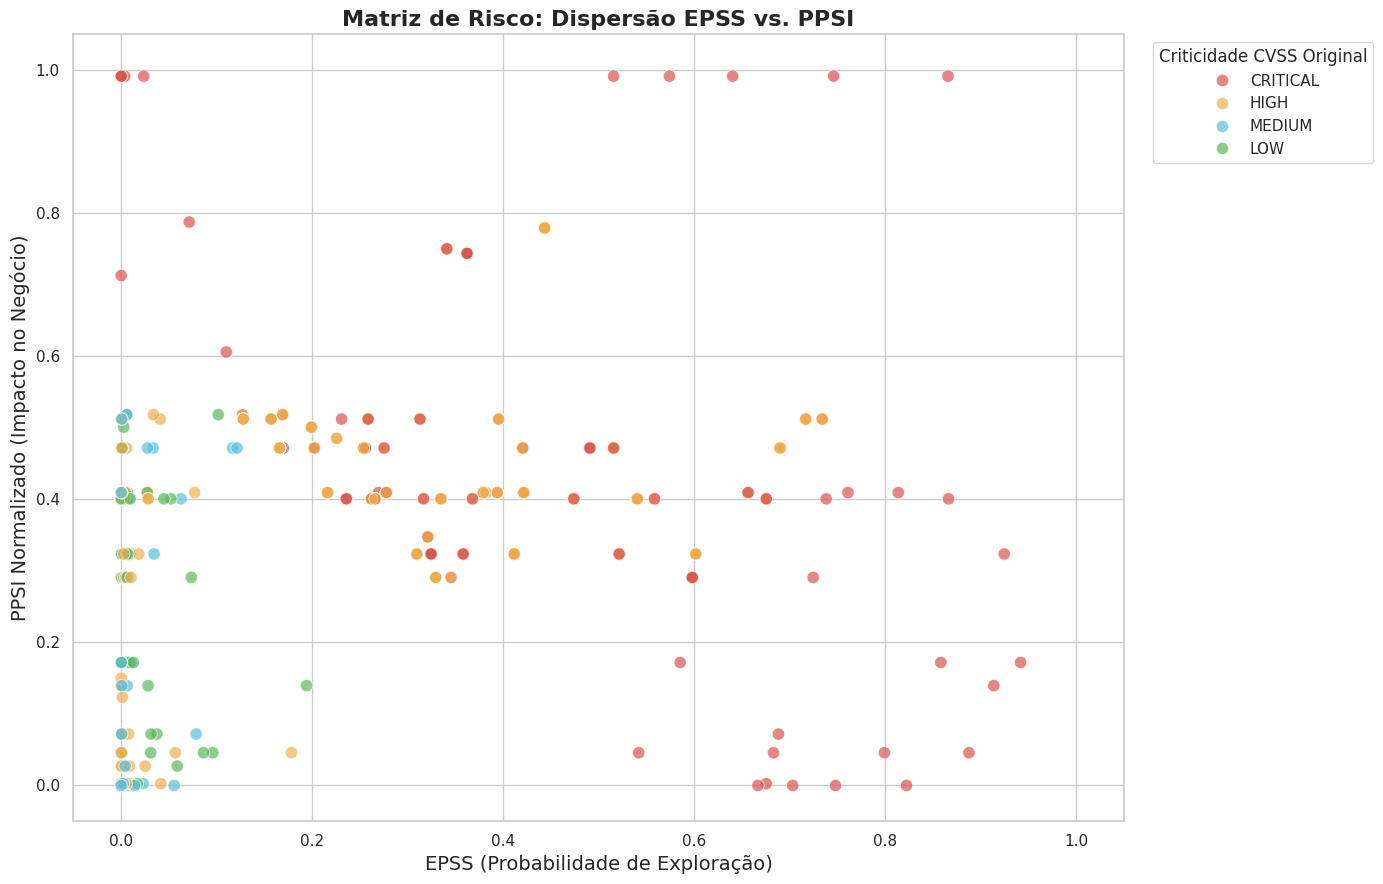

In [31]:
if df is not None:
    # --- 2. gerando o gráfico (matriz de risco) com dados reais ---
    # aumentamos a largura da figura para dar espaço à legenda
    plt.figure(figsize=(14, 9))

    # definindo a ordem e as cores para a legenda
    ordem_hue = ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']
    paleta_cores = {'CRITICAL': '#d9534f', 'high': '#f0ad4e', 'medium': '#5bc0de', 'low': '#5cb85c'}

    ax = sns.scatterplot(
        data=df,
        x='epss',
        y='ppsi_normalizado', # usando a coluna normalizada para a escala 0-1
        hue='cvss(qualitativo)', # colorimos os pontos pela severidade cvss original
        hue_order=ordem_hue,      # garantimos a ordem correta na legenda
        palette=paleta_cores,     # usamos cores intuitivas para o risco
        s=80,                     # tamanho dos pontos
        alpha=0.7
    )

    plt.title('Matriz de Risco: Dispersão EPSS vs. PPSI', fontsize=16, weight='bold')
    plt.xlabel('EPSS (Probabilidade de Exploração)', fontsize=14)
    plt.ylabel('PPSI Normalizado (Impacto no Negócio)', fontsize=14)

    # --- ajuste da legenda ---
    # move a legenda para fora da área principal do gráfico
    # bbox_to_anchor=(1.02, 1) posiciona a legenda à direita e no topo.
    # loc='upper left' ancora a legenda pelo scanto superior esquerdo.
    plt.legend(title='Criticidade CVSS Original', bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.xlim(-0.05, 1.05)
    plt.ylim(-0.05, 1.05)
    plt.grid(True)

    # ajusta o layout para garantir que a legenda externa não seja cortada
    plt.tight_layout()

    plt.show()